<div align="center">
    <h1>Linear Classifiers: Part 1</h1>
    <h3>From k-NN to Linear Decision Boundaries</h3>
    <hr>
</div>

## Learning Objectives

In this assignment, you'll transition from the k-Nearest Neighbors classifier to **linear classifiers** - a fundamental building block of modern machine learning. By the end of this notebook, you will:

- Understand why linear classifiers offer advantages over k-NN
- Implement a linear classifier trained with stochastic gradient descent (SGD)
- Visualize decision boundaries and understand how they separate classes
- Gain intuition about hyperparameters like learning rate and regularization
- Build essential foundations for understanding neural networks

## Why Move Beyond k-NN?

While k-NN is intuitive and requires no training, it has critical limitations:

| **k-NN Drawbacks** | **Linear Classifier Advantages** |
|---|---|
| Slow at test time (must compare to all training samples) | Fast predictions (just matrix multiplication) |
| Must store entire training dataset | Only stores learned weights |
| Often suboptimal performance | Better generalization on many tasks |

## What You'll Learn

Linear classifiers form the backbone of deep learning. The concepts you master here - **gradient descent**, **loss functions**, and **weight optimization** - directly apply to neural networks. Think of this as learning the fundamental building blocks before tackling more complex architectures.

In [1]:
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['image.interpolation'] = 'nearest'

%load_ext autoreload
%autoreload 2

## The Dataset: Linearly Separable Data

### Understanding Linear Separability

We'll work with a specially crafted 2D dataset that demonstrates the concept of **linear separability**. This means we can draw straight lines (or hyperplanes in higher dimensions) that cleanly separate different classes.

**Key Concepts:**
- **Linearly separable**: Classes can be perfectly separated by linear boundaries
- **Decision boundary**: The line or hyperplane that divides different classes
- **Real-world caveat**: Most real data is NOT linearly separable (we'll address this in future assignments)

### Why This Dataset?

This synthetic dataset is ideal for learning because:
1. **Visualization**: 2D data lets us see exactly what the classifier is learning
2. **Comparison**: We can directly compare performance with our k-NN implementation
3. **Intuition building**: Seeing how linear boundaries work helps understand more complex models

### What to Expect

The visualization below will show:
- Three distinct classes represented by different colors
- Clear regions where one class dominates
- The challenge: finding the optimal lines to separate these regions

Let's load the data and take a look!

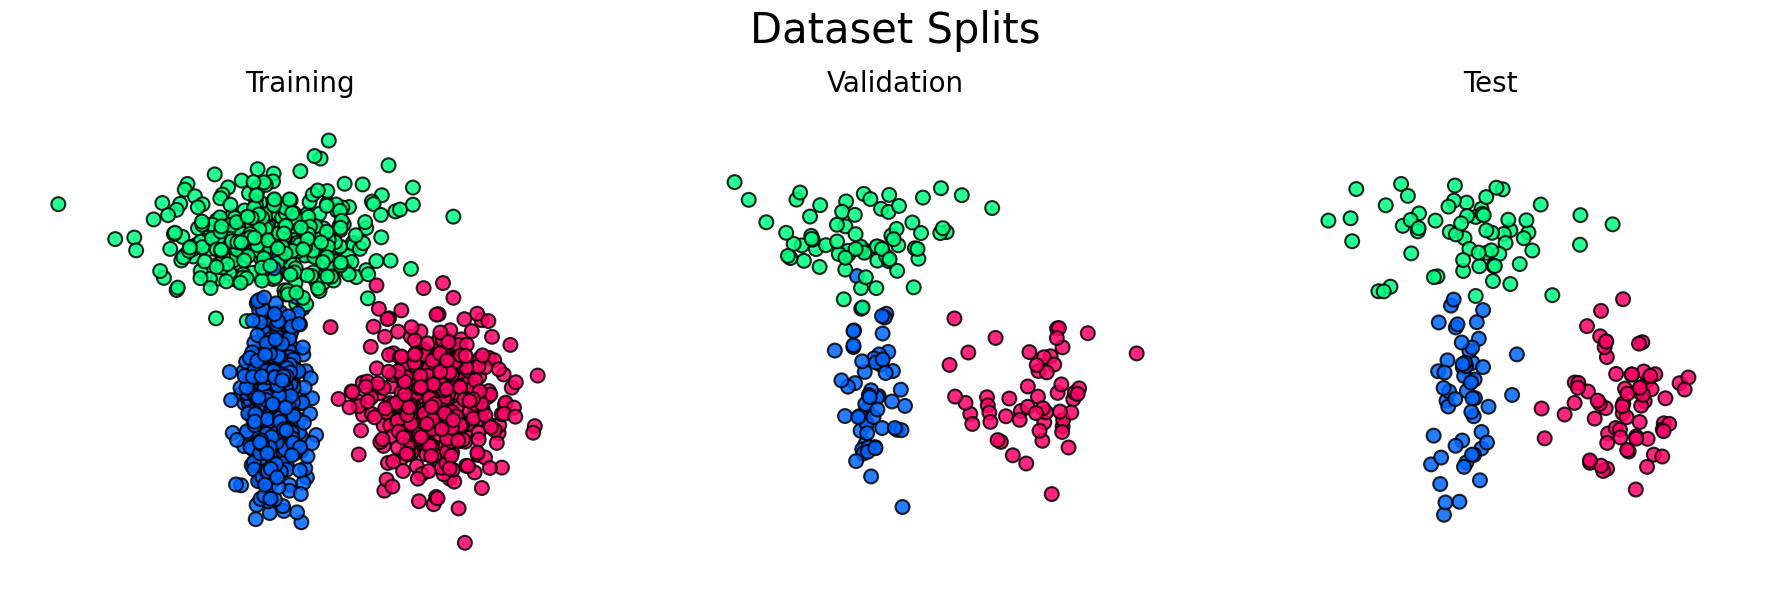

---------------- Training data ----------------
X_train shape: torch.Size([1125, 2]), y_train shape: torch.Size([1125])

---------------- Validation data ----------------
X_val shape: torch.Size([187, 2]), y_val shape: torch.Size([187])

---------------- Testing data ----------------
X_test shape: torch.Size([188, 2]), y_test shape: torch.Size([188])

---------------- Dataset info ----------------
Number of classes: 3
Number of features: 2
Number of samples in dataset: 1500
Number of samples in training set: 1125, which is 75.00% of the dataset
Number of samples in validation set: 187, which is 12.47% of the dataset
Number of samples in testing set: 188, which is 12.53% of the dataset


In [2]:
import os
import torch
import numpy as np

from utils import Data2DVisualizer, dataset_stats

notebook_dir = os.getcwd()
dataset_path = os.path.join(notebook_dir, 'data', 'datasets', 'linearly_separable.npz')

# Load the dataset
dataset = np.load(dataset_path)

X_train = torch.from_numpy(dataset['X_train']).float()
y_train = torch.from_numpy(dataset['y_train']).long()

X_val = torch.from_numpy(dataset['X_val']).float()
y_val = torch.from_numpy(dataset['y_val']).long()

X_test = torch.from_numpy(dataset['X_test']).float()
y_test = torch.from_numpy(dataset['y_test']).long()

vis = Data2DVisualizer((X_train, y_train), (X_val, y_val), (X_test, y_test))
vis.show_dataset()

num_features, num_classes, num_samples = dataset_stats(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True)

## Implementation Tasks

### Your Assignment: Building the Linear Classifier

Before running the training cell below, you need to implement four key methods in `src/assignments/linear_classifier.py`. This is where you'll translate the theory into working code!

### Assignment 3.1: Forward Pass (`forward` method)
**What to implement**: Compute the logits (raw scores) for each class
- **Input**: Data matrix `X` of shape `(N, D)` where N = samples, D = features
- **Output**: Logits matrix of shape `(N, C)` where C = classes
- **The math**: Think about how to transform input features into class scores using the learned parameters

### Assignment 3.2: Prediction (`predict` method)
**What to implement**: Convert logits to predicted class labels
- **Input**: Data matrix `X` of shape `(N, D)`
- **Output**: Predicted labels of shape `(N,)`
- **Think about**: 
  - How do you get from scores to a single class prediction?
  - Which class should you choose for each sample?
- **Hint**: You'll need to use the forward method first

### Assignment 3.3: Loss Function (`loss` method)
**What to implement**: Cross-entropy loss with L2 regularization
- **Two components to combine**:
  1. Classification loss: How wrong are our predictions?
  2. Regularization term: Penalty for having large weights
- **Consider**:
  - What loss function is appropriate for multi-class classification?
  - How do you penalize large parameter values?
  - Don't forget both W and b when regularizing
- **Available tools**: Check the hints in the code comments

### Assignment 3.4: Weight Updates (`_update_weights` method)
**What to implement**: Gradient descent step to update parameters
- **The core idea**: Move parameters in the direction that reduces loss
- **Think about**:
  - How do you access gradients in PyTorch?
  - Which direction should parameters move relative to gradients?
  - Why might you need to be careful about the computation graph?
- **Remember**: Update all parameters (both W and b)

### Tips for Success

1. **Understand the math first**: Review the linear classifier equations from lectures
2. **Check dimensions**: Use `print(tensor.shape)` liberally while debugging
3. **Start with forward**: Get the forward pass working before tackling the loss
4. **Test incrementally**: Verify each method works before moving to the next
5. **Read the hints**: The code comments contain useful suggestions

### Common Pitfalls to Avoid

- Forgetting to include bias terms
- Using the wrong dimension for operations like `argmax`
- Not regularizing all parameters in the loss
- Forgetting to use gradients in the update step

Once you've implemented these methods, the training cell below will work!

Training: 100%|██████████| 1000/1000 [00:00<00:00, 1076.54it/s]


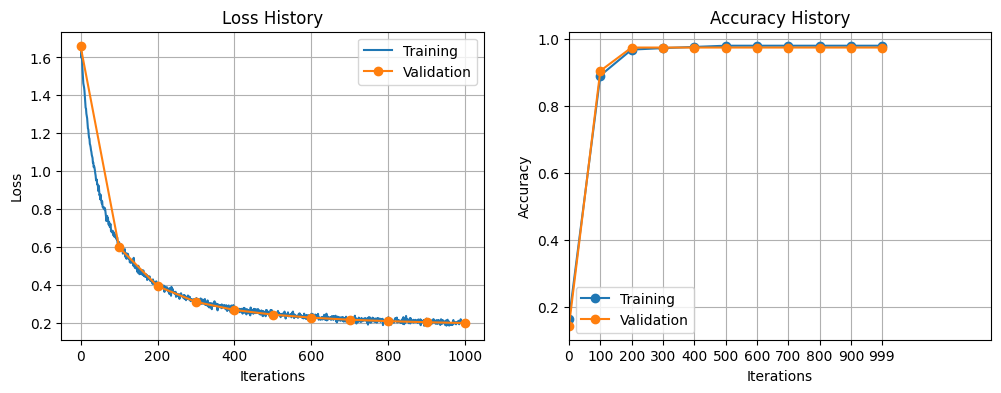

In [3]:
import torch

from utils import plot_training
from assignments import LinearClassifier

torch.random.manual_seed(69)

# Create a linear classifier
linear_classifier = LinearClassifier(num_features=2, num_classes=3,
                                     learning_rate=1e-1, num_iters=1000,
                                     batch_size=500)

# Train the classifier
loss_history, acc_history = linear_classifier.train(X_train, y_train, X_val, y_val)

# Visualize the training process
plot_training(loss_history, acc_history)

## Visualizing Decision Boundaries

### What Are Decision Boundaries?

Decision boundaries are the regions in feature space where the classifier switches its prediction from one class to another. For a linear classifier with three classes, we get:
- Three straight lines that meet at certain points
- Each line represents where two classes have equal probability
- The regions between lines show which class the model predicts

### Interpreting the Visualization

In the plot below, you'll see:
- **Colored regions**: Areas where the classifier predicts each class
- **Data points**: Training samples overlaid on the decision regions
- **Sharp boundaries**: Characteristic of linear classifiers (compare this to k-NN's potentially irregular boundaries)

### Key Observations

Notice how:
- The boundaries are perfectly straight (hence "linear" classifier)
- Some points may be misclassified even with optimal boundaries
- The model learns a global decision rule rather than memorizing local patterns

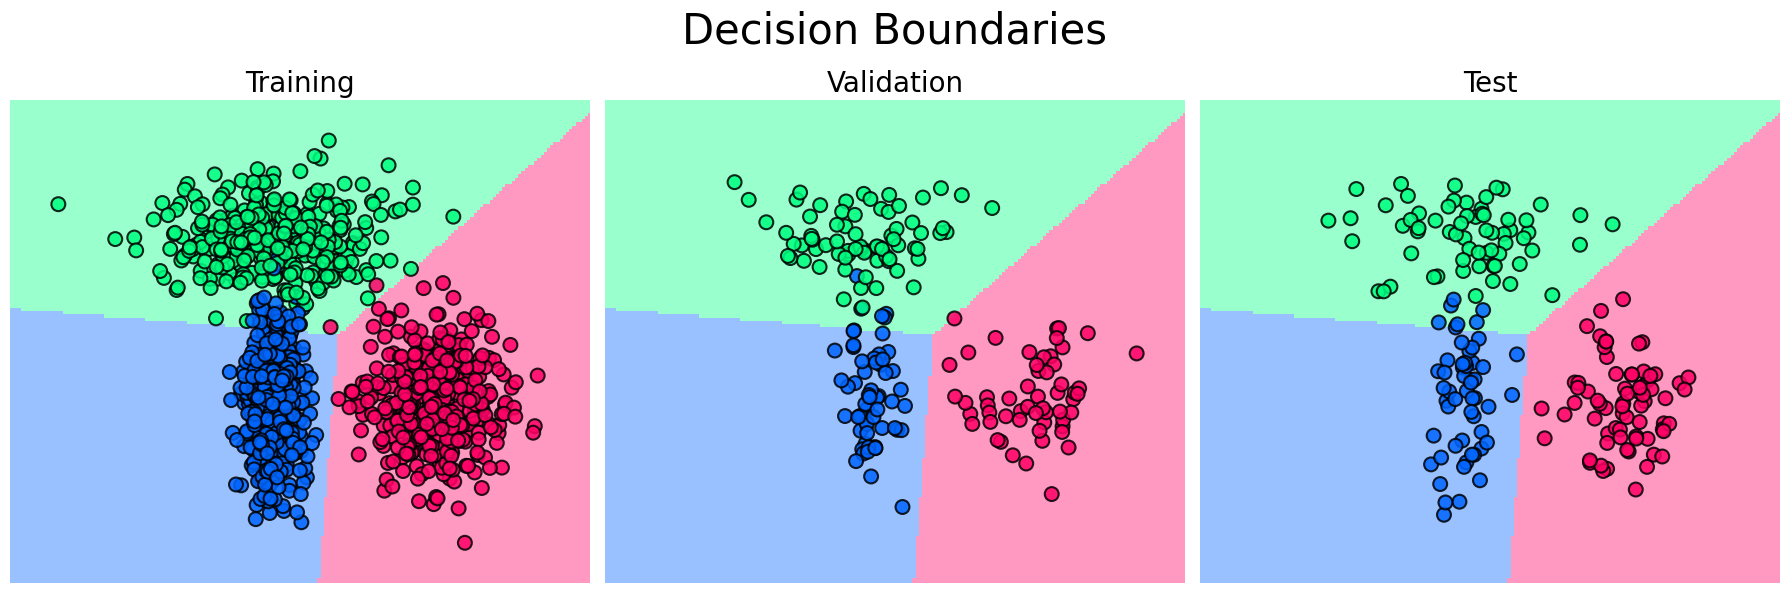

In [4]:
vis.show_decision_boundaries(linear_classifier, h=0.02)

## Understanding Decision Functions

### The Mathematics Behind Decisions

For each class, the linear classifier computes a **decision function**:
```
score(x, class_i) = w_i · x + b_i
```

Where:
- `w_i` is the weight vector for class i
- `x` is the input feature vector
- `b_i` is the bias term for class i
- The dot product `w_i · x` measures alignment between weights and features

### How Classification Works

The classifier predicts the class with the highest score:
```
prediction = argmax(score(x, class_i)) for all classes i
```

### Visualizing Decision Functions

The plots below show the decision function for each class as a surface:
- **Height**: Represents the score/confidence for that class
- **Intersection planes**: Where surfaces meet form the decision boundaries

### Key Insights

- Each class has its own linear scoring function
- The classifier is most confident far from decision boundaries
- Near boundaries, multiple classes have similar scores (uncertainty region)
- Unlike k-NN, these functions are continuous and smooth across the entire space

In [5]:
vis.show_decision_functions(linear_classifier)

## Summary and Next Steps

### What You've Learned

In this notebook, you've:
1. **Implemented** a linear classifier with SGD optimization
2. **Visualized** how linear boundaries separate classes in 2D space
3. **Understood** the mathematical foundation of linear classification
4. **Compared** linear classifiers to k-NN in terms of efficiency and decision boundaries

### Key Takeaways

| Aspect | k-NN | Linear Classifier |
|--------|------|------------------|
| Training time | O(1) - no training needed | O(n) - requires optimization |
| Prediction time | O(n) - compares to all samples | O(1) - simple matrix multiplication |
| Decision boundary | Complex, potentially irregular | Simple, always linear |
| Memory usage | Stores all training data | Only stores weights |
| Interpretability | Local decisions | Global decision rule |

### Limitations to Consider

While powerful, linear classifiers have limitations:
- **Cannot handle non-linear patterns**: If data isn't linearly separable, performance suffers
- **Limited expressiveness**: Can only learn linear relationships
- **Feature engineering**: Often requires manual feature transformation for complex data

### What's Next?

In Part 2, you'll apply linear classifiers to real image data (CIFAR-10) and discover a fascinating perspective: **linear classifiers as template matching algorithms**. This will bridge our understanding toward convolutional neural networks, which you'll explore in future assignments.